## ENSO metrics matrix plot

- Go through a collection of recipes run and collect metric values to display
- 
[CLIVAR CMIP5&6 plot](https://pcmdi.llnl.gov/pmp-preliminary-results/interactive_plot/portrait_plot/enso_metric/enso_metrics_interactive_portrait_plots_v20231121.html)

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

In [2]:
# walk and pull all matrix.csv

def read_metricscsv(recipe_output):
    df_ls = []
    for root, _dir, files in os.walk(recipe_output):
        for file in files:
            if file.endswith('.csv'):
                print('/'.join([root,file]))
                df_ls.append(pd.read_csv('/'.join([root,file]), header=None))
    metric_df = pd.concat(df_ls)
    return metric_df

In [3]:
# run normalisation on all these values
# metric_df[2] = (metric_df[2]-metric_df[2].mean())/metric_df[2].std()
# normalise each group to range.. -2 to 2
# norm = Normalize(vmin=-2, vmax=2, clip=False)

def create_norm_matrix(metric_df):
    transformls = []
    for mod in metric_df[0].unique(): #iterate model, translate metrics
        df = metric_df.loc[metric_df[0]==mod,:]
        transformls.append(df[[1,2]].set_index(1).T.rename(index={2:mod}))
    matrixdf = pd.concat(transformls)
    
    # normalise each metric/column
    for col in matrixdf.columns:
        matrixdf[col] = (matrixdf[col] - matrixdf[col].mean()) / matrixdf[col].std()
    labels_metric = {
        'eq_pr_bias': '02 eq PR bias', 'eq_pr_seacycle': '06 eq PR seasonal cycle',
        'eq_sst_bias': '03 eq SST bias', 'eq_sst_seacycle': '07 eq SST seasonal cycle',
        'eq_tauu_bias': '04 eq Taux bias', 'eq_tauu_seacycle': '08 eq Taux seasonal cycle',
        'pr_double': '01 Double ITCZ bias', 'pr_double_seacycle': '05 Double ITCZ seasonal cycle',
        'SST_TAUX': '20 SST-Taux feedback', 'TAUX_SSH': '21 Taux-SSH feedback', 'SSH_SST': '22 SSH-SST feedback', 'sst_nhf': '23 SST-NHF feedback',
        '09pattern': '09 ENSO pattern', '10lifecycle': '10 ENSO lifecycle', '11amplitude': '11 ENSO amplitude', '12seasonality': '12 ENSO seasonality',
        '13asymmetry': '13 ENSO asymmetry', '14duration': '14 ENSO duration', '15diversity': '15 ENSO diversity', 
        'DJF_pr_telecon': '16 DJF PR teleconnection', 'JJA_pr_telecon': '18 JJA PR teleconnection',
        'DJF_ts_telecon': '17 DJF TS teleconnection', 'JJA_ts_telecon': '19 JJA TS teleconnection'
    }
    # rename feedback -order
    matrixdf.rename(columns=labels_metric, inplace=True)
    matrixdf = matrixdf[sorted(matrixdf.columns)]
    
    return matrixdf
    

In [10]:

def plot_matrix(matrixdf,textsize=6):
    figure = plt.figure(dpi=300, edgecolor='black')
    
    cmap = plt.cm.RdBu_r
    cmap.set_bad(color='black')
    plt.imshow(matrixdf, cmap=cmap, vmin=-2, vmax=2)
    
    cbar = plt.colorbar(shrink=0.8)
    cbar.ax.tick_params(labelsize=6)
    
    plt.xticks(range(len(matrixdf.columns)), matrixdf.columns, rotation=90, ha='center') #
    plt.yticks(range(len(matrixdf.index)), matrixdf.index, wrap=True)
    plt.xticks(np.arange(matrixdf.shape[1]) + 0.5, minor=True)
    plt.yticks(np.arange(matrixdf.shape[0]) + 0.5, minor=True)
    
    plt.tick_params(which="both", bottom=False, left=False, labelsize=textsize, labeltop=True, labelbottom=False)
    plt.tick_params(axis='x', pad=0)
    plt.grid(which="minor", color="black", linestyle="-", linewidth=0.5)

    # plt.show()
    return figure
    

In [5]:

recipe_output = '/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_cmip6'

df = read_metricscsv(recipe_output)
df = create_norm_matrix(df)

/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_cmip6/recipe_enso_feedbacknhf_20260825_012950/work/nhf_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_cmip6/recipe_enso_climatology1_20260825_005941/work/diagnostic_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_cmip6/recipe_enso_feedback_20260825_014250/work/feedback_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_cmip6/recipe_enso_characteristics_20260824_053153/work/diagnostic_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_cmip6/recipe_enso_teleconnection_20260824_061711/work/diagnostic_metrics/plot_script/matrix.csv


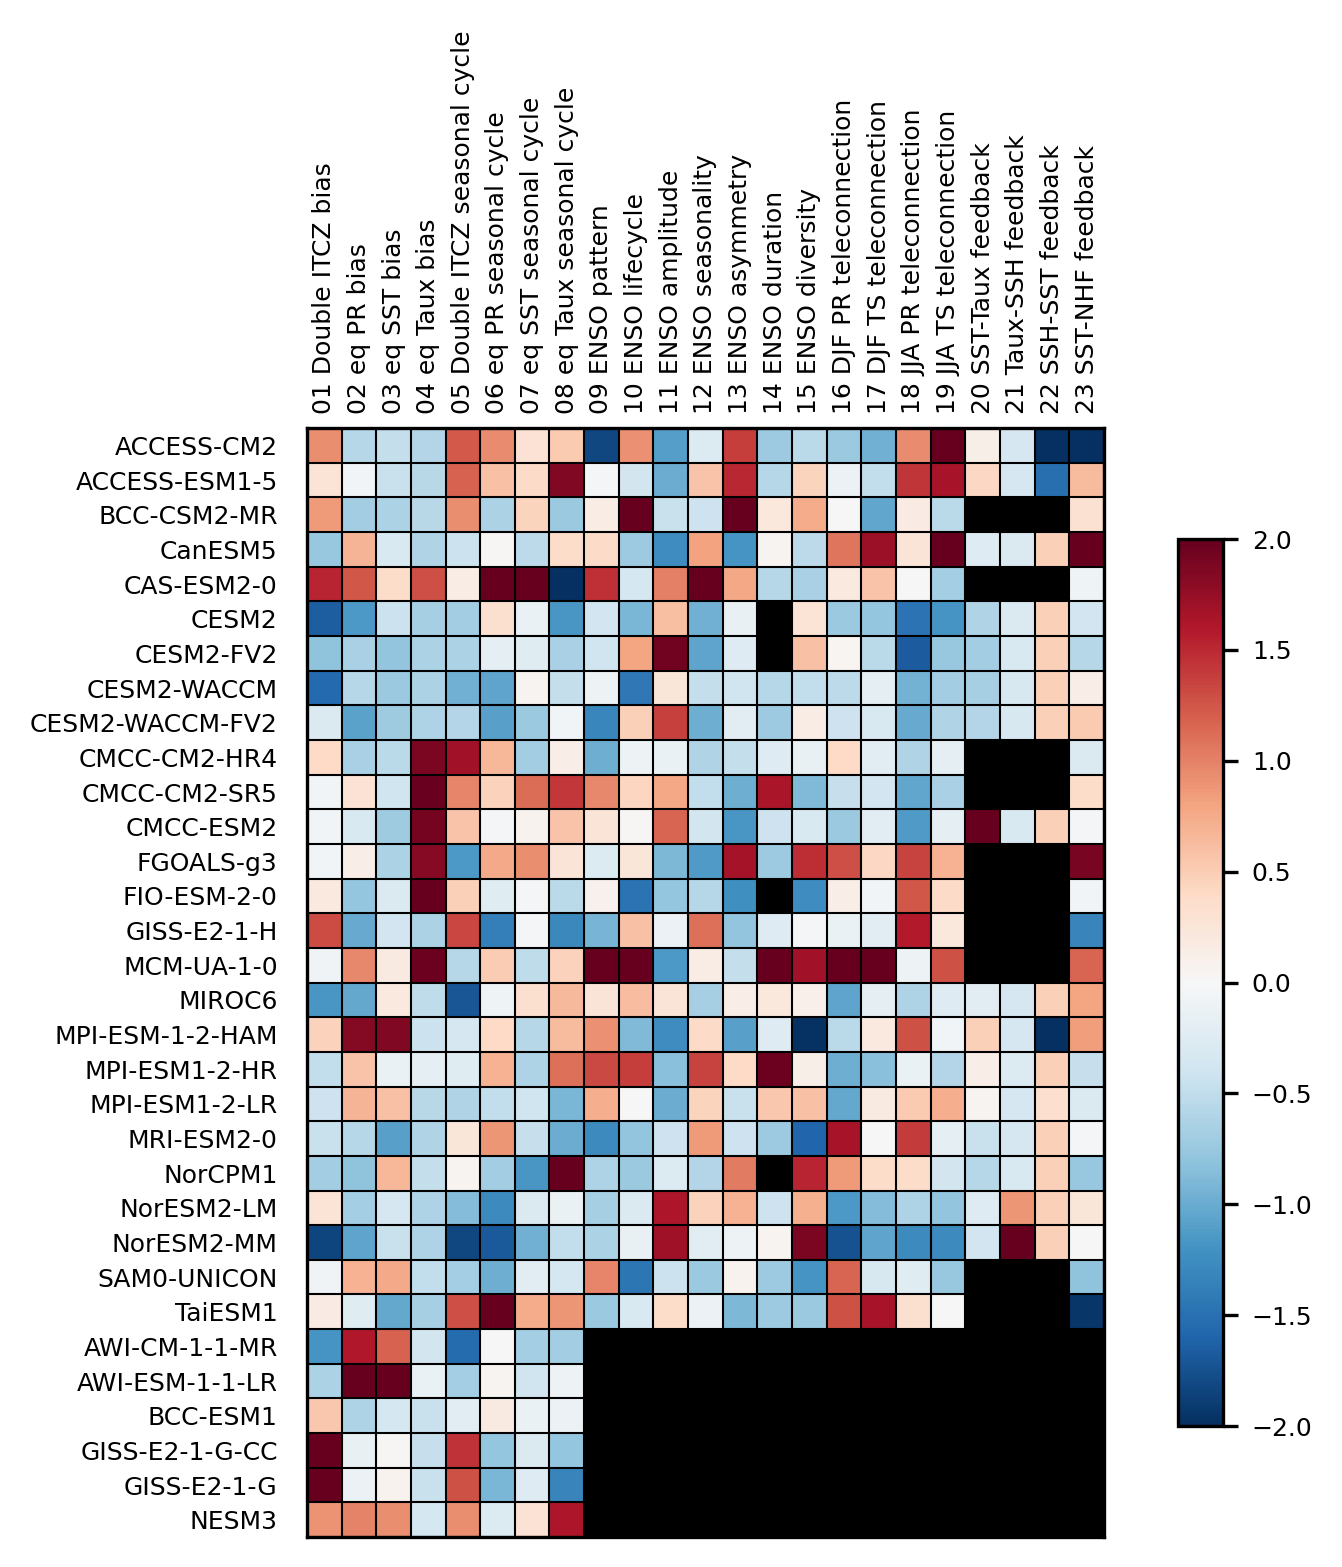

In [6]:
cmip6 = plot_matrix(df)

In [7]:
recipes = '/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_ensemble'

ensdf= read_metricscsv(recipes)
ensdf[0] = ensdf[0].str.replace('ACCESS-ESM1-6_', '')
ensdf = ensdf[ensdf[0] != 'ACCESS-ESM1-5_r1i1p1f1']
ensdf

/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_ensemble/recipe_enso_climatology1_20260826_040610/work/diagnostic_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_ensemble/recipe_enso_teleconnection_20260826_065029/work/diagnostic_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_ensemble/recipe_enso_feedbacknhf_20260827_024603/work/nhf_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_ensemble/recipe_enso_characteristics_20260826_062047/work/diagnostic_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_ensemble/recipe_enso_feedback_20260826_063141/work/feedback_metrics/plot_script/matrix.csv


,0,1,2
1,r10i1p1f1,eq_pr_bias,1.691607
2,r11i1p1f1,eq_pr_bias,1.550204
3,r12i1p1f1,eq_pr_bias,1.656541
4,r13i1p1f1,eq_pr_bias,1.701905
5,r14i1p1f1,eq_pr_bias,1.591878
...,...,...,...
79,r5i1p1f1,SSH_SST,69.604805
80,r6i1p1f1,SSH_SST,69.649551
81,r7i1p1f1,SSH_SST,69.402657
82,r8i1p1f1,SSH_SST,72.629478


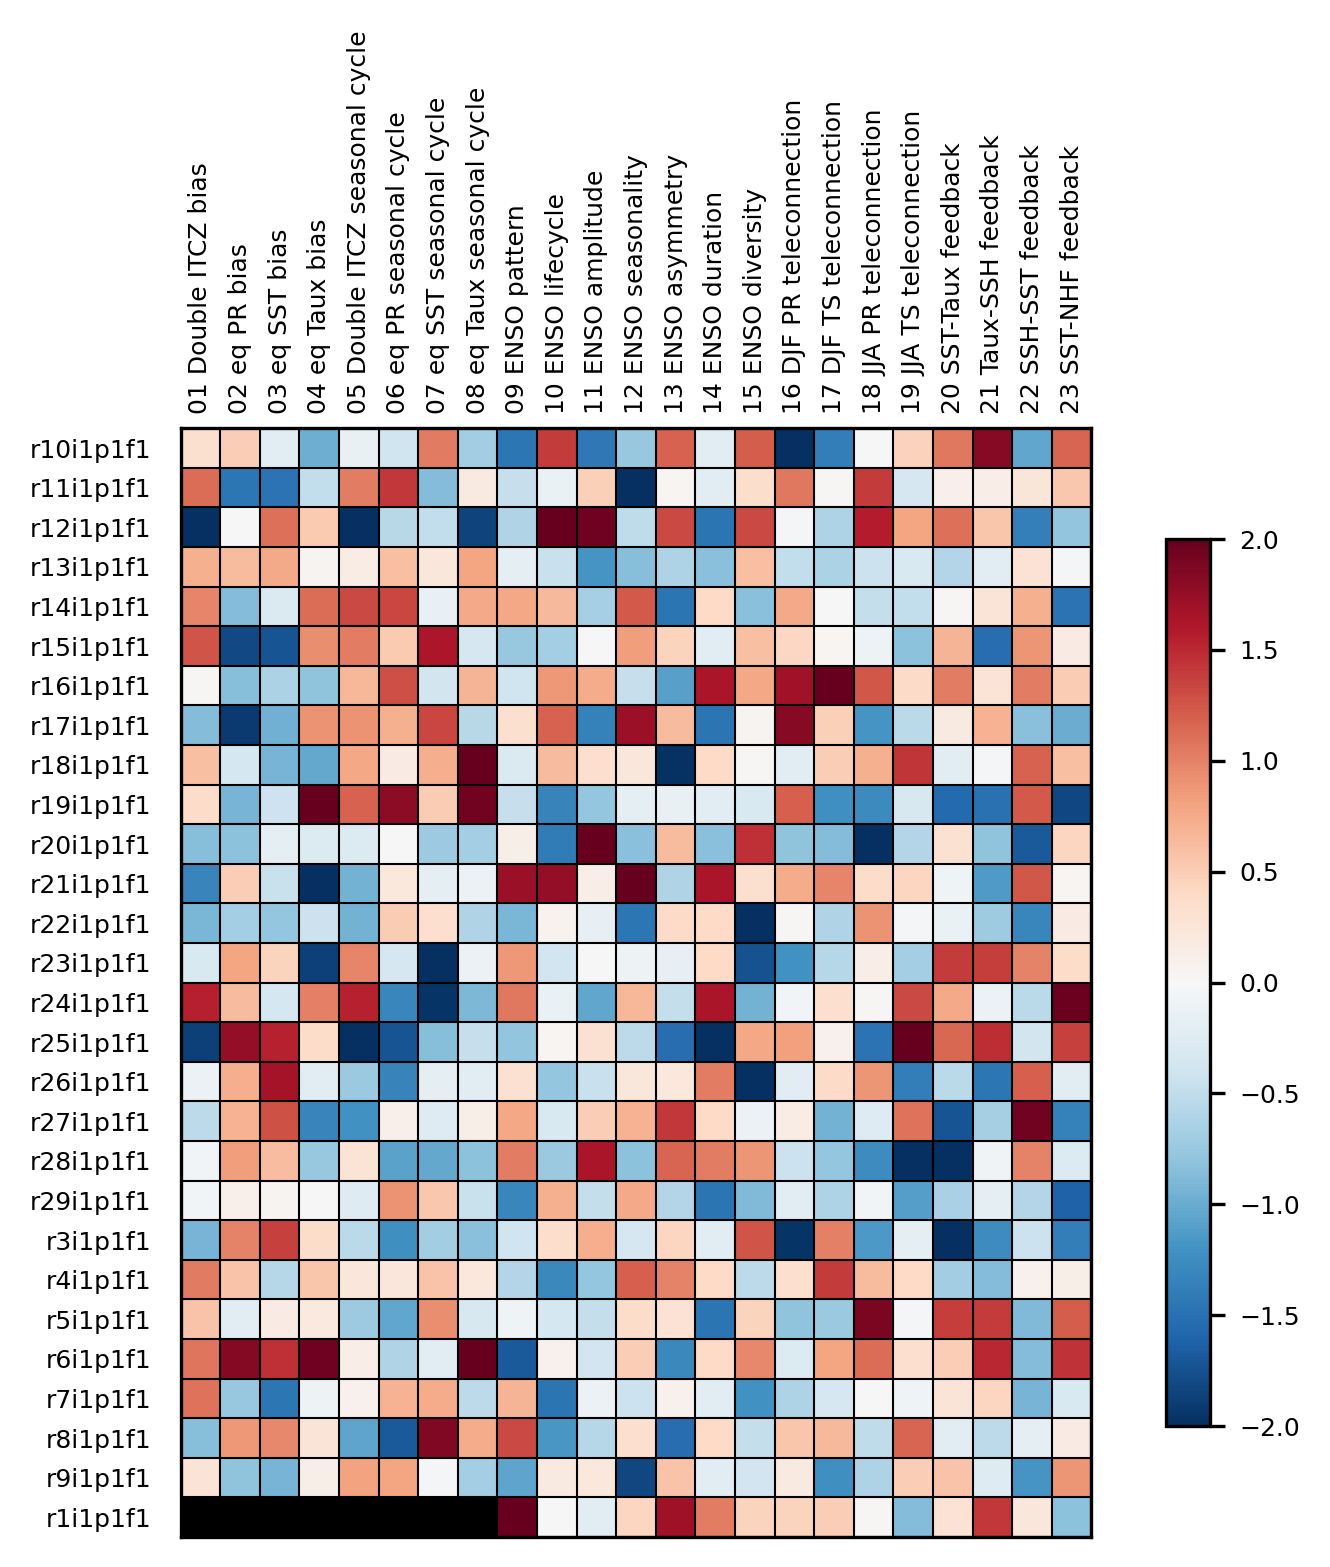

In [8]:
# ESM1.6 esm-hist ensemble

recipes = '/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_ensemble'

# ensdf = read_metricscsv(recipes)
ensdf = create_norm_matrix(ensdf)

ensembles = plot_matrix(ensdf)

/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_cmip6/recipe_enso_feedbacknhf_20260825_012950/work/nhf_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_cmip6/recipe_enso_climatology1_20260825_005941/work/diagnostic_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_cmip6/recipe_enso_feedback_20260825_014250/work/feedback_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_cmip6/recipe_enso_characteristics_20260824_053153/work/diagnostic_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_cmip6/recipe_enso_teleconnection_20260824_061711/work/diagnostic_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_ensemble/recipe_enso_climatology1_20260826_040610/work/diagnostic_metrics/plot_script/matrix.csv
/scratch/iq82/fc6164/esmvaltool_output/enso_metrics_ensemble/recipe_enso_teleconnection_20260826_065029/work/diagnostic_metrics/pl

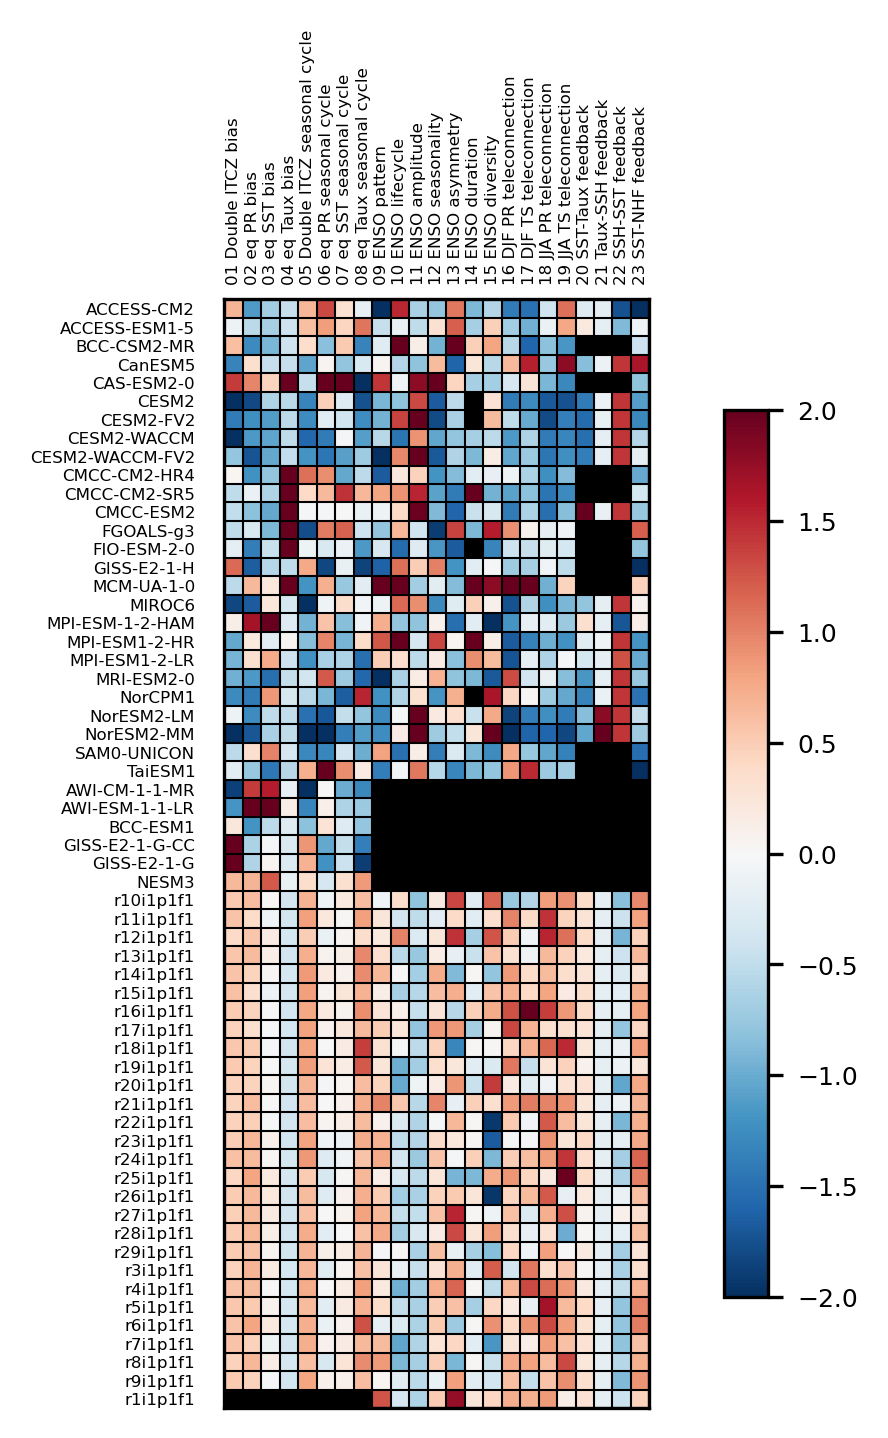

In [11]:
# for normalise metric across all
df = read_metricscsv(recipe_output)

ensdf= read_metricscsv(recipes)
ensdf[0] = ensdf[0].str.replace('ACCESS-ESM1-6_', '')
ensdf = ensdf[ensdf[0] != 'ACCESS-ESM1-5_r1i1p1f1']

df_both =  pd.concat([df,ensdf])

df_both = create_norm_matrix(df_both)

both = plot_matrix(df_both, 4)